downloading Olivetti faces from https://ndownloader.figshare.com/files/5976027 to /Users/diegopez/scikit_learn_data


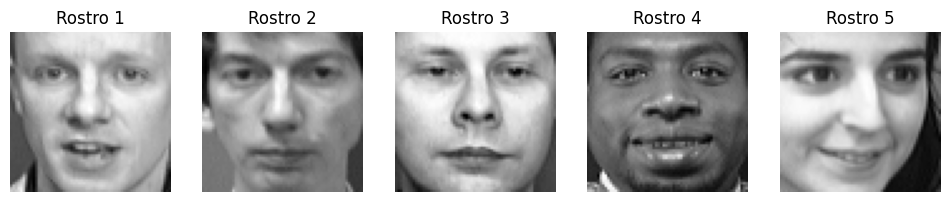

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces
from sklearn.decomposition import PCA

dataset = fetch_olivetti_faces(shuffle=True, random_state=42)
faces = dataset.images
X = dataset.data

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(faces[i], cmap='gray')
    ax.set_title(f"Rostro {i+1}")
    ax.axis('off')
plt.show()

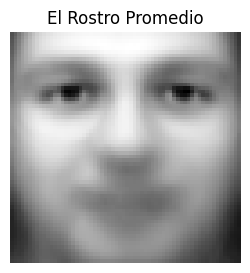

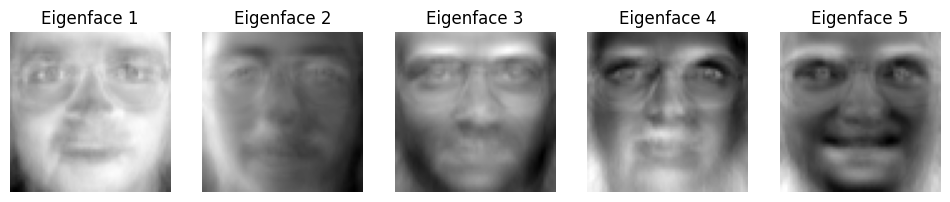

In [2]:
rostro_promedio = X.mean(axis=0)

plt.figure(figsize=(3, 3))
plt.imshow(rostro_promedio.reshape(64, 64), cmap='gray')
plt.title("El Rostro Promedio")
plt.axis('off')
plt.show()

pca = PCA(n_components=150, whiten=True, random_state=42)
pca.fit(X)

eigenfaces = pca.components_.reshape((150, 64, 64))

fig, axes = plt.subplots(1, 5, figsize=(12, 3))
for i, ax in enumerate(axes):
    ax.imshow(eigenfaces[i], cmap='gray')
    ax.set_title(f"Eigenface {i+1}")
    ax.axis('off')
plt.show()

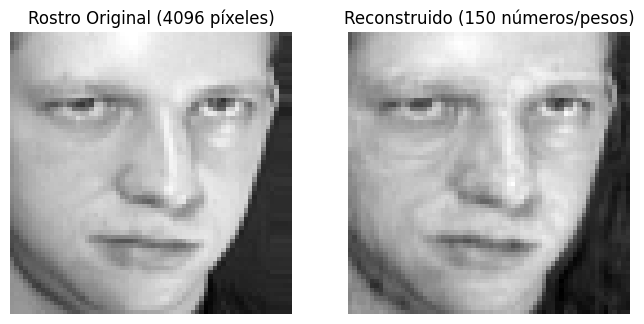

Los 150 números que definen esta cara empiezan con: [ 0.45  0.63  2.25  1.27 -0.78] ...


In [3]:
rostro_original = X[10]

pesos_receta = pca.transform(rostro_original.reshape(1, -1))

rostro_reconstruido = pca.inverse_transform(pesos_receta)

fig, axes = plt.subplots(1, 2, figsize=(8, 4))

axes[0].imshow(rostro_original.reshape(64, 64), cmap='gray')
axes[0].set_title("Rostro Original (4096 píxeles)")
axes[0].axis('off')

axes[1].imshow(rostro_reconstruido.reshape(64, 64), cmap='gray')
axes[1].set_title("Reconstruido (150 números/pesos)")
axes[1].axis('off')

plt.show()

print(f"Los 150 números que definen esta cara empiezan con: {np.round(pesos_receta[0][:5], 2)} ...")